# Himalayan Climbing Expeditions (1905-2019)
### ETL Python Project: Extraction and EDA

**Dataset:** Himalayan Climbing Expeditions (TidyTuesday, 22 Sep 2020) - https://github.com/rfordatascience/tidytuesday/tree/main/data/2020/2020-09-22

The data comes from The Himalayan Database (https://www.himalayandatabase.com/), which records expeditions to the peaks of the Nepal Himalaya. There are three CSV files: `peaks.csv`, `expeditions.csv` and `members.csv`.

## 1. Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Extract the data

In [2]:
peaks = pd.read_csv("../data/raw/peaks.csv")
expeditions = pd.read_csv("../data/raw/expeditions.csv")
members = pd.read_csv("../data/raw/members.csv")

# copies of the original data, we will not change these
raw_peaks = peaks.copy()
raw_expeditions = expeditions.copy()
raw_members = members.copy()

## 3. EDA - Basic exploration

### 3.1 Rows and columns

In [3]:
print("peaks:", peaks.shape)
print("expeditions:", expeditions.shape)
print("members:", members.shape)

peaks: (468, 8)
expeditions: (10364, 16)
members: (76519, 21)


### 3.2 Column names

In [4]:
print(list(peaks.columns))
print()
print(list(expeditions.columns))
print()
print(list(members.columns))

['peak_id', 'peak_name', 'peak_alternative_name', 'height_metres', 'climbing_status', 'first_ascent_year', 'first_ascent_country', 'first_ascent_expedition_id']

['expedition_id', 'peak_id', 'peak_name', 'year', 'season', 'basecamp_date', 'highpoint_date', 'termination_date', 'termination_reason', 'highpoint_metres', 'members', 'member_deaths', 'hired_staff', 'hired_staff_deaths', 'oxygen_used', 'trekking_agency']

['expedition_id', 'member_id', 'peak_id', 'peak_name', 'year', 'season', 'sex', 'age', 'citizenship', 'expedition_role', 'hired', 'highpoint_metres', 'success', 'solo', 'oxygen_used', 'died', 'death_cause', 'death_height_metres', 'injured', 'injury_type', 'injury_height_metres']


### 3.3 Data types

In [5]:
print(peaks.dtypes)

peak_id                           str
peak_name                         str
peak_alternative_name             str
height_metres                   int64
climbing_status                   str
first_ascent_year             float64
first_ascent_country              str
first_ascent_expedition_id        str
dtype: object


In [6]:
print(expeditions.dtypes)

expedition_id             str
peak_id                   str
peak_name                 str
year                    int64
season                    str
basecamp_date             str
highpoint_date            str
termination_date          str
termination_reason        str
highpoint_metres      float64
members                 int64
member_deaths           int64
hired_staff             int64
hired_staff_deaths      int64
oxygen_used              bool
trekking_agency           str
dtype: object


In [7]:
print(members.dtypes)

expedition_id               str
member_id                   str
peak_id                     str
peak_name                   str
year                      int64
season                      str
sex                         str
age                     float64
citizenship                 str
expedition_role             str
hired                      bool
highpoint_metres        float64
success                    bool
solo                       bool
oxygen_used                bool
died                       bool
death_cause                 str
death_height_metres     float64
injured                    bool
injury_type                 str
injury_height_metres    float64
dtype: object


### 3.4 Sample records

In [8]:
peaks.head()

,peak_id,peak_name,peak_alternative_name,height_metres,climbing_status,first_ascent_year,first_ascent_country,first_ascent_expedition_id
0,AMAD,Ama Dablam,Amai Dablang,6814,Climbed,1961.0,"New Zealand, USA, UK",AMAD61101
1,AMPG,Amphu Gyabjen,NaN,5630,Climbed,1953.0,UK,AMPG53101
2,ANN1,Annapurna I,NaN,8091,Climbed,1950.0,France,ANN150101
3,ANN2,Annapurna II,NaN,7937,Climbed,1960.0,"UK, Nepal",ANN260101
4,ANN3,Annapurna III,NaN,7555,Climbed,1961.0,India,ANN361101


In [9]:
expeditions.head()

,expedition_id,peak_id,peak_name,year,season,basecamp_date,highpoint_date,termination_date,termination_reason,highpoint_metres,members,member_deaths,hired_staff,hired_staff_deaths,oxygen_used,trekking_agency
0,ANN260101,ANN2,Annapurna II,1960,Spring,1960-03-15,1960-05-17,NaN,Success (main peak),7937.0,10,0,9,0,True,NaN
1,ANN269301,ANN2,Annapurna II,1969,Autumn,1969-09-25,1969-10-22,1969-10-26,Success (main peak),7937.0,10,0,0,0,False,NaN
2,ANN273101,ANN2,Annapurna II,1973,Spring,1973-03-16,1973-05-06,NaN,Success (main peak),7937.0,6,0,8,0,False,NaN
3,ANN278301,ANN2,Annapurna II,1978,Autumn,1978-09-08,1978-10-02,1978-10-05,"Bad weather (storms, high winds)",7000.0,2,0,0,0,False,NaN
4,ANN279301,ANN2,Annapurna II,1979,Autumn,NaN,1979-10-18,1979-10-20,"Bad weather (storms, high winds)",7160.0,3,0,0,0,False,NaN


In [10]:
members.head()

,expedition_id,member_id,peak_id,peak_name,year,season,sex,age,citizenship,expedition_role,...,highpoint_metres,success,solo,oxygen_used,died,death_cause,death_height_metres,injured,injury_type,injury_height_metres
0,AMAD78301,AMAD78301-01,AMAD,Ama Dablam,1978,Autumn,M,40.0,France,Leader,...,NaN,False,False,False,False,NaN,NaN,False,NaN,NaN
1,AMAD78301,AMAD78301-02,AMAD,Ama Dablam,1978,Autumn,M,41.0,France,Deputy Leader,...,6000.0,False,False,False,False,NaN,NaN,False,NaN,NaN
2,AMAD78301,AMAD78301-03,AMAD,Ama Dablam,1978,Autumn,M,27.0,France,Climber,...,NaN,False,False,False,False,NaN,NaN,False,NaN,NaN
3,AMAD78301,AMAD78301-04,AMAD,Ama Dablam,1978,Autumn,M,40.0,France,Exp Doctor,...,6000.0,False,False,False,False,NaN,NaN,False,NaN,NaN
4,AMAD78301,AMAD78301-05,AMAD,Ama Dablam,1978,Autumn,M,34.0,France,Climber,...,NaN,False,False,False,False,NaN,NaN,False,NaN,NaN


### 3.5 Summary statistics

In [11]:
peaks.describe()

,height_metres,first_ascent_year
count,468.000000,336.000000
mean,6656.636752,1979.077381
std,571.912791,100.205460
min,5407.000000,201.000000
25%,6235.750000,1963.000000
50%,6559.500000,1982.000000
75%,6911.000000,2008.000000
max,8850.000000,2019.000000


In [12]:
expeditions.describe()

,year,highpoint_metres,members,member_deaths,hired_staff,hired_staff_deaths
count,10364.000000,9950.000000,10364.000000,10364.000000,10364.000000,10364.000000
mean,2001.156310,7408.923819,5.953300,0.076032,2.776920,0.030683
std,14.710054,1012.628339,5.428004,0.377665,5.081277,0.284747
min,1905.000000,3500.000000,0.000000,0.000000,0.000000,0.000000
25%,1994.000000,6700.000000,2.000000,0.000000,0.000000,0.000000
50%,2005.000000,7300.000000,5.000000,0.000000,1.000000,0.000000
75%,2012.000000,8188.000000,8.000000,0.000000,3.000000,0.000000
max,2019.000000,8850.000000,99.000000,10.000000,99.000000,11.000000


In [13]:
members[["year", "age", "highpoint_metres"]].describe()

,year,age,highpoint_metres
count,76519.000000,73022.000000,54686.000000
mean,2000.361714,37.334297,7470.680759
std,14.780560,10.395602,1040.063830
min,1905.000000,7.000000,3800.000000
25%,1991.000000,29.000000,6700.000000
50%,2004.000000,36.000000,7400.000000
75%,2012.000000,44.000000,8400.000000
max,2019.000000,85.000000,8850.000000


### 3.6 Unique values

In [14]:
print("Peaks:", peaks["peak_id"].nunique())
print("Expeditions:", expeditions["expedition_id"].nunique())
print("Members:", members["member_id"].nunique())
print("Citizenships:", members["citizenship"].nunique())
print("Trekking agencies:", expeditions["trekking_agency"].nunique())
print("Years:", expeditions["year"].min(), "to", expeditions["year"].max())

Peaks: 468
Expeditions: 10363
Members: 76518
Citizenships: 212
Trekking agencies: 827
Years: 1905 to 2019


In [15]:
print(expeditions["season"].value_counts())
print()
print(peaks["climbing_status"].value_counts())
print()
print(members["sex"].value_counts())

season
Autumn     5064
Spring     4875
Winter      315
Summer      108
Unknown       2
Name: count, dtype: int64

climbing_status
Climbed      341
Unclimbed    127
Name: count, dtype: int64

sex
M    69473
F     7044
Name: count, dtype: int64


## 4. EDA - Data quality checks

### 4.1 Missing values

In [16]:
for name, df in [("peaks", peaks), ("expeditions", expeditions), ("members", members)]:
    missing = df.isnull().sum()
    print(name)
    print(missing[missing > 0])
    print()

peaks
peak_alternative_name         223
first_ascent_year             132
first_ascent_country          132
first_ascent_expedition_id    135
dtype: int64



expeditions
peak_name              1
basecamp_date       1095
highpoint_date       650
termination_date    2380
highpoint_metres     414
trekking_agency     1710
dtype: int64



members
peak_name                  15
sex                         2
age                      3497
citizenship                10
expedition_role            21
highpoint_metres        21833
death_cause             75413
death_height_metres     75451
injury_type             74807
injury_height_metres    75510
dtype: int64



`members` has a lot of missing values in the death and injury columns because most climbers did not die or get injured. That is normal. `highpoint_metres` and `age` are real missing data.

In [17]:
print("Members with missing age (%):", round(members["age"].isnull().mean() * 100, 1))
print("Members with missing highpoint (%):", round(members["highpoint_metres"].isnull().mean() * 100, 1))
print("Expeditions with missing trekking agency (%):", round(expeditions["trekking_agency"].isnull().mean() * 100, 1))

Members with missing age (%): 4.6
Members with missing highpoint (%): 28.5
Expeditions with missing trekking agency (%): 16.5


### 4.2 Duplicate records

In [18]:
print("peaks duplicates:", peaks.duplicated().sum())
print("expeditions duplicates:", expeditions.duplicated().sum())
print("members duplicates:", members.duplicated().sum())

peaks duplicates: 0
expeditions duplicates: 0
members duplicates: 0


In [19]:
# repeated ids
print("peak_id repeated:", peaks["peak_id"].duplicated().sum())
print("expedition_id repeated:", expeditions["expedition_id"].duplicated().sum())
print("member_id repeated:", members["member_id"].duplicated().sum())

peak_id repeated: 0
expedition_id repeated: 1
member_id repeated: 1


In [20]:
expeditions[expeditions["expedition_id"].duplicated(keep=False)]

,expedition_id,peak_id,peak_name,year,season,basecamp_date,highpoint_date,termination_date,termination_reason,highpoint_metres,members,member_deaths,hired_staff,hired_staff_deaths,oxygen_used,trekking_agency
2883,KANG10101,KANG,Kangchenjunga,1910,Spring,NaN,NaN,NaN,Did not attempt climb,NaN,1,0,0,0,False,NaN
6819,KANG10101,KANG,Kangchenjunga,2010,Spring,2010-03-24,2010-04-29,2010-05-01,Success (main peak),8586.0,4,0,2,0,True,Windhorse Trekking


The same `expedition_id` (KANG10101) is used for two different expeditions, one in 1910 and one in 2010. So `expedition_id` is not unique and cannot be a primary key by itself. The same thing happens with `member_id`.

### 4.3 Data types

In [21]:
print(expeditions[["basecamp_date", "highpoint_date", "termination_date"]].dtypes)
print(expeditions["basecamp_date"].head(3).tolist())

basecamp_date       str
highpoint_date      str
termination_date    str
dtype: object
['1960-03-15', '1969-09-25', '1973-03-16']


The dates are stored as text, we will change them to datetime.

### 4.4 Invalid or inconsistent values

In [22]:
# do all foreign keys have a matching peak / expedition?
print("expeditions -> peaks:", (~expeditions["peak_id"].isin(peaks["peak_id"])).sum())
print("members -> expeditions:", (~members["expedition_id"].isin(expeditions["expedition_id"])).sum())
print("members -> peaks:", (~members["peak_id"].isin(peaks["peak_id"])).sum())

expeditions -> peaks: 1
members -> expeditions: 0
members -> peaks: 15


In [23]:
expeditions[~expeditions["peak_id"].isin(peaks["peak_id"])]

,expedition_id,peak_id,peak_name,year,season,basecamp_date,highpoint_date,termination_date,termination_reason,highpoint_metres,members,member_deaths,hired_staff,hired_staff_deaths,oxygen_used,trekking_agency
2546,SPHU63301,SPHU,NaN,1963,Autumn,1963-10-12,1963-10-22,1963-10-28,Success (main peak),6433.0,11,0,4,0,False,NaN


Peak `SPHU` is used in expeditions and members but it is not in the `peaks` table.

In [24]:
# date order
bc = pd.to_datetime(expeditions["basecamp_date"])
hp = pd.to_datetime(expeditions["highpoint_date"])
tm = pd.to_datetime(expeditions["termination_date"])
print("highpoint before basecamp:", (hp < bc).sum())
print("termination before basecamp:", (tm < bc).sum())

highpoint before basecamp: 0
termination before basecamp: 0


In [25]:
# do the deaths in members match the deaths in expeditions?
print("died in members:", members["died"].sum())
print("member_deaths + hired_staff_deaths in expeditions:", expeditions["member_deaths"].sum() + expeditions["hired_staff_deaths"].sum())

died in members: 1106
member_deaths + hired_staff_deaths in expeditions: 1106


In [26]:
# expedition highpoint should not be higher than the peak
check = expeditions.merge(peaks[["peak_id", "height_metres"]], on="peak_id")
print("Highpoint higher than the peak height:", (check["highpoint_metres"] > check["height_metres"]).sum())
check[check["highpoint_metres"] > check["height_metres"]][["peak_name", "year", "highpoint_metres", "height_metres"]].head()

Highpoint higher than the peak height: 49


,peak_name,year,highpoint_metres,height_metres
175,Cholatse,1985,6440.0,6423
756,Lobuje East,1991,6110.0,6090
879,Cholatse,1988,6440.0,6423
998,Cholatse,1984,6440.0,6423
1153,Cholatse,1992,6440.0,6423


### 4.5 Unexpected categories and formatting

In [27]:
print(expeditions["termination_reason"].value_counts())

termination_reason
Success (main peak)                                                             5581
Bad weather (storms, high winds)                                                1307
Bad conditions (deep snow, avalanching, falling ice, or rock)                   1097
Illness, AMS, exhaustion, or frostbite                                           458
Route technically too difficult, lack of experience, strength, or motivation     438
Other                                                                            320
Accident (death or serious injury)                                               299
Did not attempt climb                                                            233
Lack (or loss) of supplies or equipment                                          220
Success (subpeak)                                                                126
Unknown                                                                           96
Lack of time                                  

`Unknown` is used as a category in `season` and `termination_reason`. There are also 15 different termination reasons and two kinds of success (main peak and subpeak).

In [28]:
mixed = members[members["citizenship"].str.contains("/", na=False)]
print("Members with two countries in citizenship:", len(mixed))
print(mixed["citizenship"].head(8).tolist())

Members with two countries in citizenship: 300
['UK/Hong Kong', 'W Germany/Iran', 'Spain/USA', 'Austria/Brazil', 'Germany/Iran', 'UK/Italy', 'USA/Switzerland', 'W Germany/Iran']


Some members have two countries in one value (`Australia/UK`). This makes the citizenship column inconsistent.

In [29]:
print(peaks["first_ascent_country"].dropna().head(5).tolist())

['New Zealand, USA, UK', 'UK', 'France', 'UK, Nepal', 'India']


`first_ascent_country` also has several countries in one cell.

### 4.6 Outliers

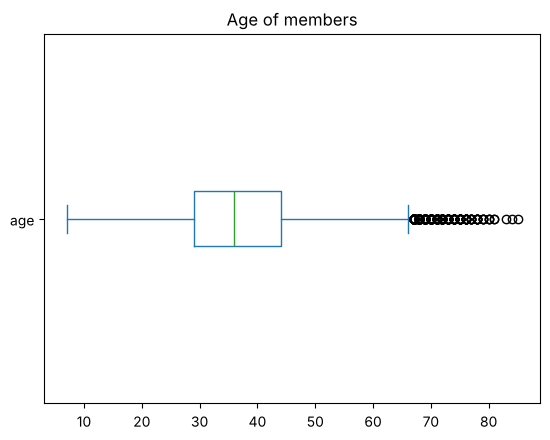

In [30]:
members["age"].plot(kind="box", vert=False)
plt.title("Age of members")
plt.show()

In [31]:
members.sort_values("age").head(3)[["peak_name", "year", "age", "expedition_role"]]

,peak_name,year,age,expedition_role
18609,Manaslu,1984,7.0,Member
9244,Everest,1984,12.0,Climber/Cleaner
54393,Everest,2010,13.0,Climber


In [32]:
members.sort_values("age", ascending=False).head(5)[["peak_name", "year", "age"]]

,peak_name,year,age
69589,Everest,2017,85.0
74839,Tsartse,2018,84.0
64509,Everest,2015,83.0
59982,Everest,2013,81.0
55098,Everest,2011,81.0


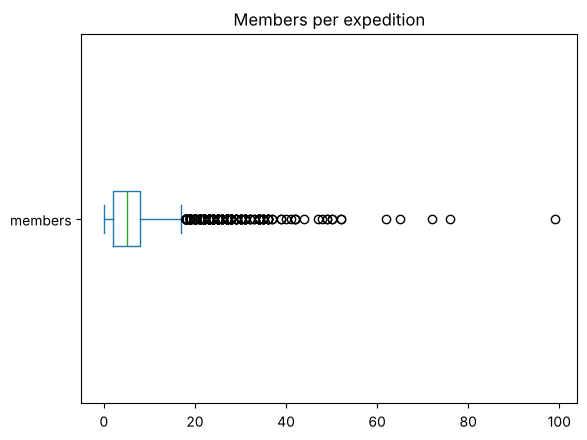

In [33]:
expeditions["members"].plot(kind="box", vert=False)
plt.title("Members per expedition")
plt.show()

In [34]:
expeditions.sort_values("members", ascending=False).head(3)[["peak_name", "year", "members"]]

,peak_name,year,members
512,Everest,1988,99
6011,Everest,2008,76
8370,Himlung Himal,2013,72


A 7 year old member and an 85 year old member look strange, but they are probably real (Everest has had very old climbers). Big expeditions with 99 members also happened. We will keep them but check the age 7 row later.

## 5. EDA - Exploring the data

### 5.1 Expeditions per year

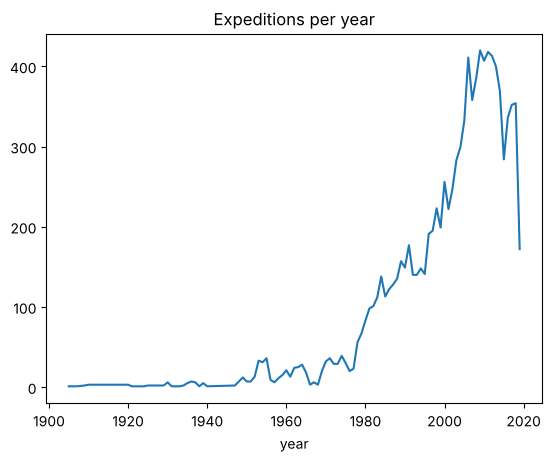

In [35]:
per_year = expeditions.groupby("year").size()
per_year.plot(kind="line")
plt.title("Expeditions per year")
plt.show()

### 5.2 Expeditions by season

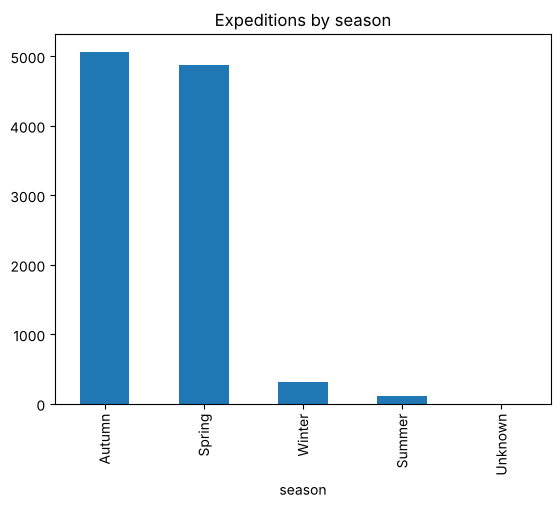

In [36]:
expeditions["season"].value_counts().plot(kind="bar")
plt.title("Expeditions by season")
plt.show()

### 5.3 Most attempted peaks and their success rate

In [37]:
expeditions["success"] = expeditions["termination_reason"].str.startswith("Success")

top_peaks = expeditions["peak_name"].value_counts().head(10)
print(top_peaks)

peak_name
Everest         2149
Ama Dablam      1366
Cho Oyu         1332
Manaslu          632
Lhotse           429
Dhaulagiri I     383
Makalu           356
Baruntse         308
Pumori           265
Annapurna I      243
Name: count, dtype: int64


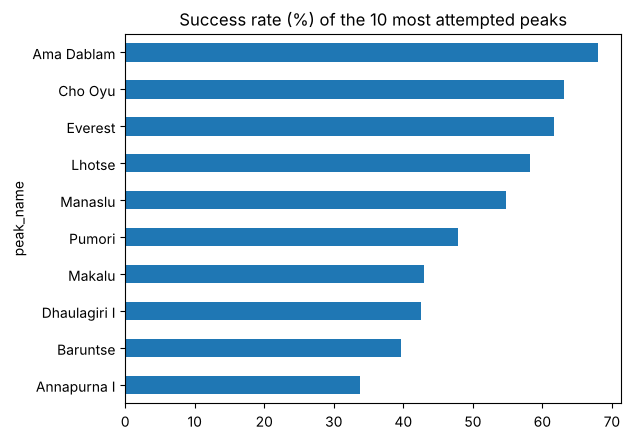

In [38]:
success_rate = expeditions.groupby("peak_name")["success"].mean() * 100
success_rate[top_peaks.index].sort_values().plot(kind="barh")
plt.title("Success rate (%) of the 10 most attempted peaks")
plt.show()

### 5.4 Oxygen and success

In [39]:
oxygen = members.groupby("oxygen_used")["success"].mean() * 100
print(oxygen)

oxygen_used
False    25.851834
True     77.502331
Name: success, dtype: float64


In [40]:
# only the very high peaks (8000 m and above)
high = members.merge(peaks[["peak_id", "height_metres"]], on="peak_id")
high = high[high["height_metres"] >= 8000]
print(high.groupby("oxygen_used")["success"].mean() * 100)

oxygen_used
False    15.755254
True     77.905748
Name: success, dtype: float64


### 5.5 Members by citizenship

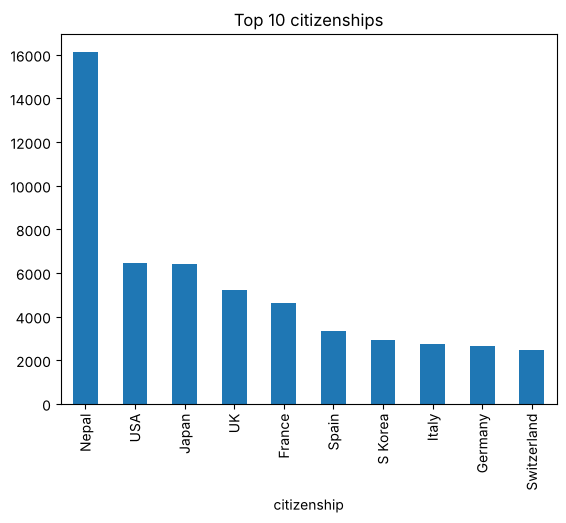

In [41]:
members["citizenship"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 citizenships")
plt.show()

### 5.6 Age of members

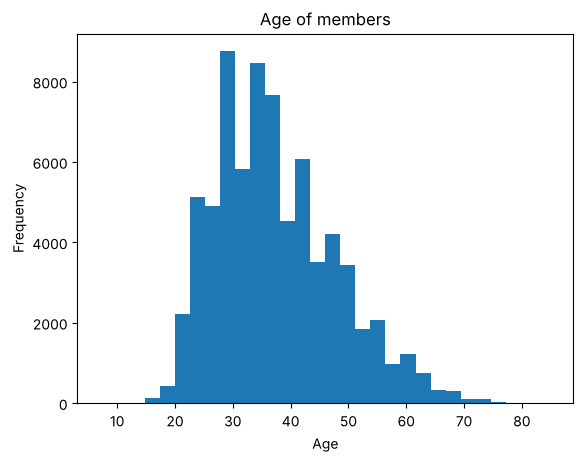

Average age: 37.3


In [42]:
members["age"].plot(kind="hist", bins=30)
plt.title("Age of members")
plt.xlabel("Age")
plt.show()

print("Average age:", round(members["age"].mean(), 1))

### 5.7 Women climbers over the years

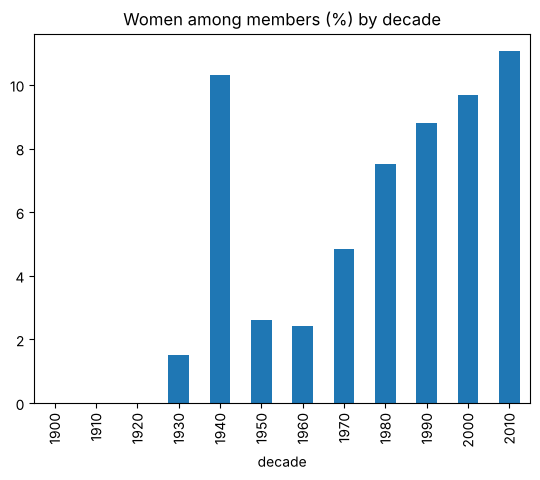

In [43]:
members["decade"] = (members["year"] // 10) * 10
female_share = members.groupby("decade")["sex"].apply(lambda s: (s == "F").mean() * 100)
female_share.plot(kind="bar")
plt.title("Women among members (%) by decade")
plt.show()

### 5.8 Deaths

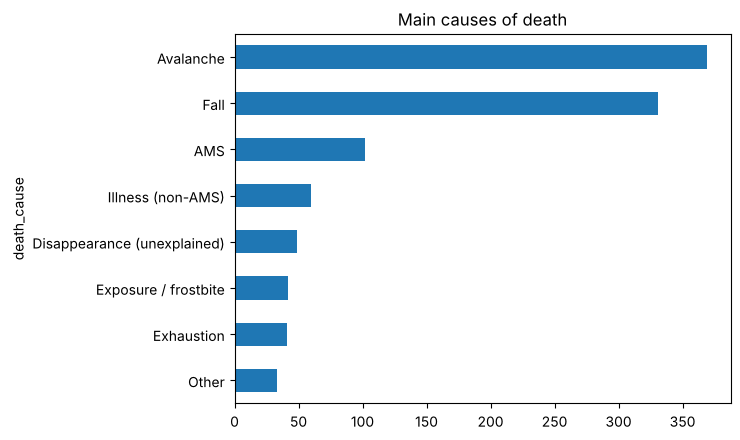

In [44]:
members["death_cause"].value_counts().head(8).plot(kind="barh")
plt.title("Main causes of death")
plt.gca().invert_yaxis()
plt.show()

In [45]:
death_by_peak = expeditions.groupby("peak_name")["member_deaths"].sum().sort_values(ascending=False)
death_by_peak.head(5)

peak_name
Everest         186
Manaslu          69
Dhaulagiri I     63
Annapurna I      54
Cho Oyu          42
Name: member_deaths, dtype: int64

### 5.9 First ascents

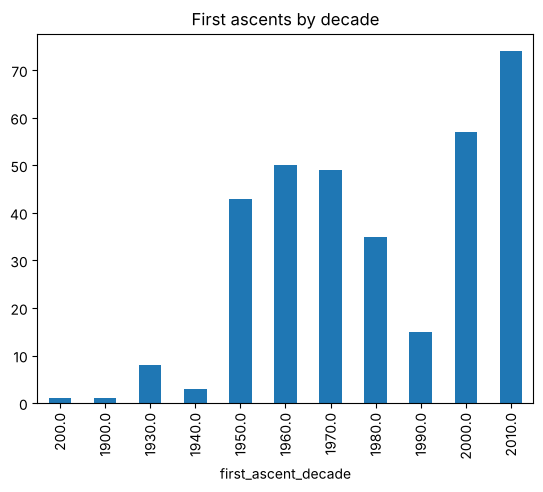

In [46]:
peaks["first_ascent_decade"] = (peaks["first_ascent_year"] // 10) * 10
peaks.groupby("first_ascent_decade").size().plot(kind="bar")
plt.title("First ascents by decade")
plt.show()

In [47]:
peaks.sort_values("height_metres", ascending=False).head(5)[["peak_name", "height_metres", "first_ascent_year"]]

,peak_name,height_metres,first_ascent_year
42,Everest,8850,1953.0
91,Kangchenjunga,8586,1955.0
112,Lhotse,8516,1956.0
188,Yalung Kang,8505,1973.0
122,Makalu,8485,1955.0


## 6. Does the dataset meet the project requirements?

In [48]:
print("peaks:", len(peaks), "rows,", raw_peaks.shape[1], "columns")
print("expeditions:", len(expeditions), "rows,", raw_expeditions.shape[1], "columns")
print("members:", len(members), "rows,", raw_members.shape[1], "columns")
print("Total rows:", len(peaks) + len(expeditions) + len(members))

peaks: 468 rows, 8 columns
expeditions: 10364 rows, 16 columns
members: 76519 rows, 21 columns
Total rows: 87351


| Requirement | Result |
|---|---|
| Source is CSV files read with Pandas | Yes, 3 CSV files |
| At least a few hundred rows | Yes, 468 peaks, 10,364 expeditions and 76,519 members |
| Enough complexity, not only a few simple columns | Yes, 8, 16 and 21 columns |
| Multiple related tables possible | Yes: peaks, expeditions and members are linked with `peak_id` and `expedition_id` |
| Data quality problems to clean | Yes (see below) |

**Problems found that we will fix in the cleaning phase**
1. Dates are stored as text.
2. `expedition_id` and `member_id` are not unique (KANG10101 is used in 1910 and 2010).
3. Peak `SPHU` is missing from the `peaks` table.
4. `citizenship` and `first_ascent_country` sometimes have more than one country in one value.
5. Missing `age`, `highpoint_metres`, `trekking_agency` and dates.
6. `Unknown` is used as a category in `season` and `termination_reason`.
7. 49 expeditions have a highpoint higher than the peak itself.
8. One member is 7 years old, needs checking.

**Conclusion:** the dataset meets the requirements.